# Get ERD diagram from DataJoint

In [1]:
cd ..

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%run env.py
%run run.py connect

[2026-03-13 13:52:28,719][INFO]: Connecting root@127.0.0.1:3309
[2026-03-13 13:52:28,752][INFO]: Connected root@127.0.0.1:3309


In [3]:
import datajoint as dj

In [5]:
import datajoint as dj
import warnings
import importlib
import pkgutil

warnings.simplefilter(action="ignore", category=FutureWarning)

# Load base schemas
from base.base_min_schemas.base_schemas.schemas import exp, mice

# Auto-import all vr4mice schema submodules so their dj.Schema objects are registered
import vr4mice.schema as vr4mice_schema

for module_info in pkgutil.iter_modules(vr4mice_schema.__path__, vr4mice_schema.__name__ + "."):
    importlib.import_module(module_info.name)

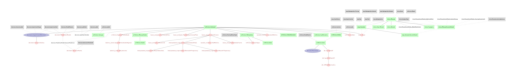

In [6]:
import sys

# Collect schemas from module dictionaries without triggering lazy imports
seen = set()
schemas = []
for module in list(sys.modules.values()):
    if module is None:
        continue
    module_dict = getattr(module, "__dict__", None)
    if not module_dict:
        continue
    for obj in module_dict.values():
        if isinstance(obj, dj.Schema):
            if id(obj) in seen:
                continue
            seen.add(id(obj))
            schemas.append(obj)

schemas = sorted(schemas, key=lambda schema: schema.database)

if not schemas:
    raise RuntimeError("No DataJoint schemas found. Import schema modules first.")

diagram = None
for schema in schemas:
    if diagram is None:
        diagram = dj.Diagram(schema)
    else:
        diagram = diagram + dj.Diagram(schema)

diagram.draw()
diagram.save(filename="vr4mice-erd.png", format="png")